# Feature Engineering — Diabetes 130-US Hospitals

Builds on the EDA to produce a clean, model-ready dataset.

**Steps:**
1. Preprocessing — drop unusable columns, handle missing values, filter invalid encounters
2. IDS code mapping — decode admission/discharge/source IDs to categories
3. ICD-9 → CCS categories — collapse 700+ codes to ~14 clinical groups
4. Charlson Comorbidity Index — approximation from diagnosis codes
5. Medication features — binary encoding + burden score
6. Demographic & lab encoding — age midpoint, gender binary, A1C/glucose ordinal
7. Aggregated features — prior visits, care intensity composite
8. Patient-level split — 70 / 15 / 15 by `patient_nbr` (no leakage)
9. Save processed datasets

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 120

In [2]:
df = pd.read_csv("../data/diabetic_data.csv")
print(f"Raw dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head(2)

Raw dataset: 101,766 rows x 50 columns


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30


## 1. Preprocessing

In [3]:
# Replace '?' sentinel with NaN
df = df.replace("?", np.nan)

# Drop weight — 96.9% missing, essentially unusable
df = df.drop(columns=["weight"])
print("Dropped: weight")

# Filter out encounters where readmission was impossible:
# 11=Expired, 13=Hospice/home, 14=Hospice/medical, 19-21=Expired (Medicaid hospice)
DEAD_IDS = {11, 13, 14, 19, 20, 21}
n_before = len(df)
df = df[~df["discharge_disposition_id"].isin(DEAD_IDS)].copy()
print(f"Dropped {n_before - len(df):,} deceased/hospice encounters -> {len(df):,} remain")

# Drop 3 'Unknown/Invalid' gender rows
df = df[df["gender"] != "Unknown/Invalid"].copy()

# Fill high-missingness categoricals with 'Unknown' (do NOT impute with clinical values)
df["race"] = df["race"].fillna("Unknown")
df["medical_specialty"] = df["medical_specialty"].fillna("Unknown")
df["payer_code"] = df["payer_code"].fillna("Unknown")

print(f"\nDataset after cleaning: {df.shape[0]:,} rows x {df.shape[1]} columns")

Dropped: weight
Dropped 2,423 deceased/hospice encounters -> 99,343 remain

Dataset after cleaning: 99,340 rows x 49 columns


In [4]:
# Drop near-zero-variance medications (confirmed in EDA: <= 3 non-'No' records each)
NEAR_ZERO_MEDS = ["examide", "citoglipton", "troglitazone",
                  "metformin-pioglitazone", "glimepiride-pioglitazone"]
df = df.drop(columns=NEAR_ZERO_MEDS)
print(f"Dropped {len(NEAR_ZERO_MEDS)} near-zero-variance medication columns")

# Target variable: 1 = readmitted within 30 days, 0 = all other outcomes
df["readmit_30"] = (df["readmitted"] == "<30").astype(int)
print(f"\nTarget: readmit_30")
print(f"  Positive: {df['readmit_30'].sum():,} ({df['readmit_30'].mean()*100:.1f}%)")
print(f"  Negative: {(df['readmit_30'] == 0).sum():,} ({(df['readmit_30'] == 0).mean()*100:.1f}%)")

Dropped 5 near-zero-variance medication columns

Target: readmit_30
  Positive: 11,314 (11.4%)
  Negative: 88,026 (88.6%)


## 2. IDS Code Mapping

Decode `admission_type_id`, `discharge_disposition_id`, and `admission_source_id` using `IDS_mapping.csv`.
We collapse the fine-grained IDS codes into interpretable categories for modeling.

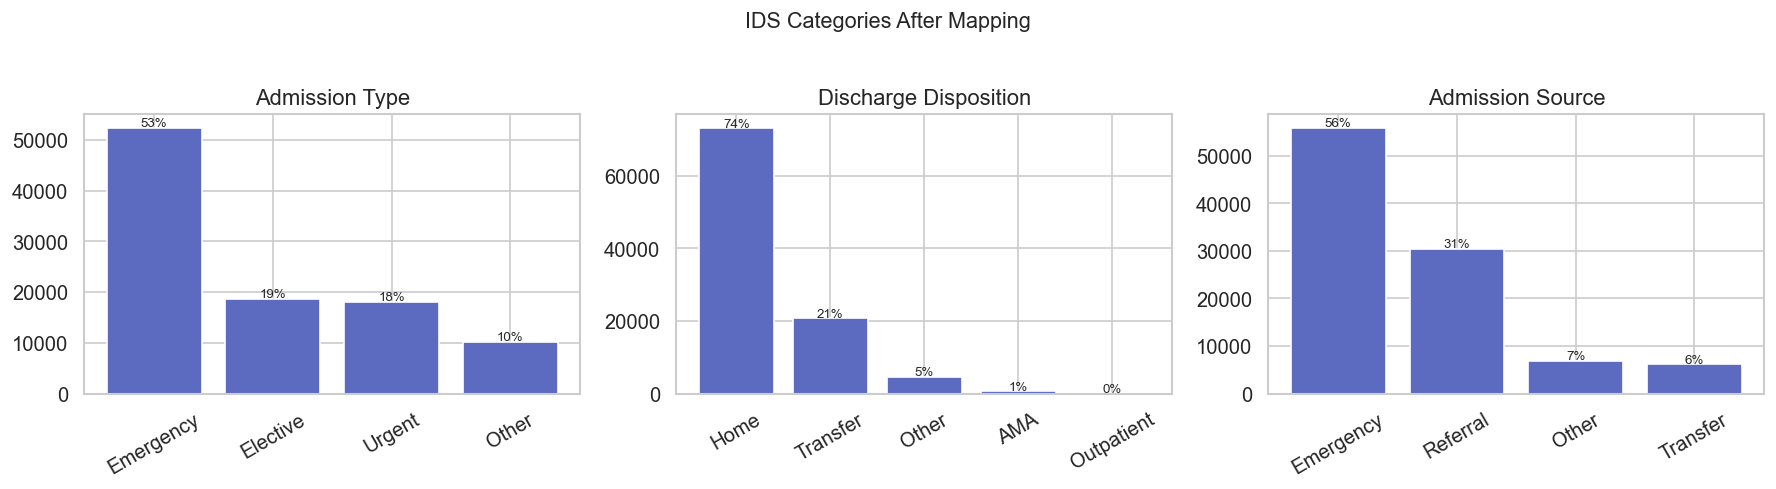

In [5]:
def simplify_admission_type(type_id):
    """Collapse 8 admission type codes to 4 interpretable categories."""
    mapping = {1: "Emergency", 2: "Urgent", 3: "Elective"}
    return mapping.get(type_id, "Other")

def simplify_discharge(disp_id):
    """Collapse 29 discharge codes to 5 categories meaningful for readmission risk."""
    if disp_id in {1, 6, 8}:
        return "Home"
    elif disp_id in {2, 3, 4, 5, 10, 15, 22, 23, 24, 27, 28, 29, 30}:
        return "Transfer"
    elif disp_id == 7:
        return "AMA"           # Against Medical Advice — high readmission risk
    elif disp_id in {9, 12, 16, 17}:
        return "Outpatient"
    else:
        return "Other"

def simplify_admission_source(src_id):
    """Collapse 26 source codes to 4 categories."""
    if src_id == 7:
        return "Emergency"
    elif src_id in {1, 2, 3}:
        return "Referral"
    elif src_id in {4, 5, 6, 10, 18, 22, 25, 26}:
        return "Transfer"
    else:
        return "Other"

df["admission_type_cat"]   = df["admission_type_id"].map(simplify_admission_type)
df["discharge_cat"]         = df["discharge_disposition_id"].map(simplify_discharge)
df["admission_source_cat"] = df["admission_source_id"].map(simplify_admission_source)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
        ["admission_type_cat", "discharge_cat", "admission_source_cat"],
        ["Admission Type", "Discharge Disposition", "Admission Source"]):
    vc = df[col].value_counts()
    ax.bar(vc.index, vc.values, color="#5C6BC0", edgecolor="white")
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=30)
    for i, (k, v) in enumerate(vc.items()):
        ax.text(i, v + 300, f"{v/len(df)*100:.0f}%", ha="center", fontsize=8)
plt.suptitle("IDS Categories After Mapping", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 3. ICD-9 → CCS Category Mapping

The 700+ unique ICD-9 codes per diagnosis slot are mapped to 14 broad CCS (Clinical Classifications Software) categories.
This prevents cardinality explosion and makes the features interpretable.

In [6]:
def icd9_to_ccs(code):
    """Map an ICD-9 code string to a broad CCS category."""
    if pd.isna(code):
        return "Unknown"
    c = str(code).strip().upper()
    if c.startswith("V"):
        return "Supplementary/V"
    if c.startswith("E"):
        return "External/E"
    try:
        num = float(c.split(".")[0])
    except ValueError:
        return "Unknown"
    if   1   <= num <= 139: return "Infectious/Parasitic"
    elif 140  <= num <= 239: return "Neoplasms"
    elif 240  <= num <= 279: return "Endocrine/Metabolic"   # includes diabetes (250)
    elif 280  <= num <= 289: return "Blood"
    elif 290  <= num <= 319: return "Mental"
    elif 320  <= num <= 389: return "Nervous System"
    elif 390  <= num <= 459: return "Circulatory"           # CHF (428), MI (410)
    elif 460  <= num <= 519: return "Respiratory"
    elif 520  <= num <= 579: return "Digestive"
    elif 580  <= num <= 629: return "Genitourinary"
    elif 680  <= num <= 709: return "Skin"
    elif 710  <= num <= 739: return "Musculoskeletal"
    elif 780  <= num <= 799: return "Symptoms/Signs"
    elif 800  <= num <= 999: return "Injury/Poisoning"
    else:                    return "Other"

for col in ["diag_1", "diag_2", "diag_3"]:
    df[f"ccs_{col}"] = df[col].apply(icd9_to_ccs)

print("CCS categories in primary diagnosis:")
print(df["ccs_diag_1"].value_counts().to_string())

CCS categories in primary diagnosis:
ccs_diag_1
Circulatory             29584
Endocrine/Metabolic     11304
Respiratory              9919
Digestive                9072
Symptoms/Signs           7601
Injury/Poisoning         6851
Genitourinary            4963
Musculoskeletal          4935
Neoplasms                3131
Infectious/Parasitic     2553
Skin                     2508
Mental                   2256
Supplementary/V          1632
Nervous System           1181
Blood                    1092
Other                     737
Unknown                    20
External/E                  1


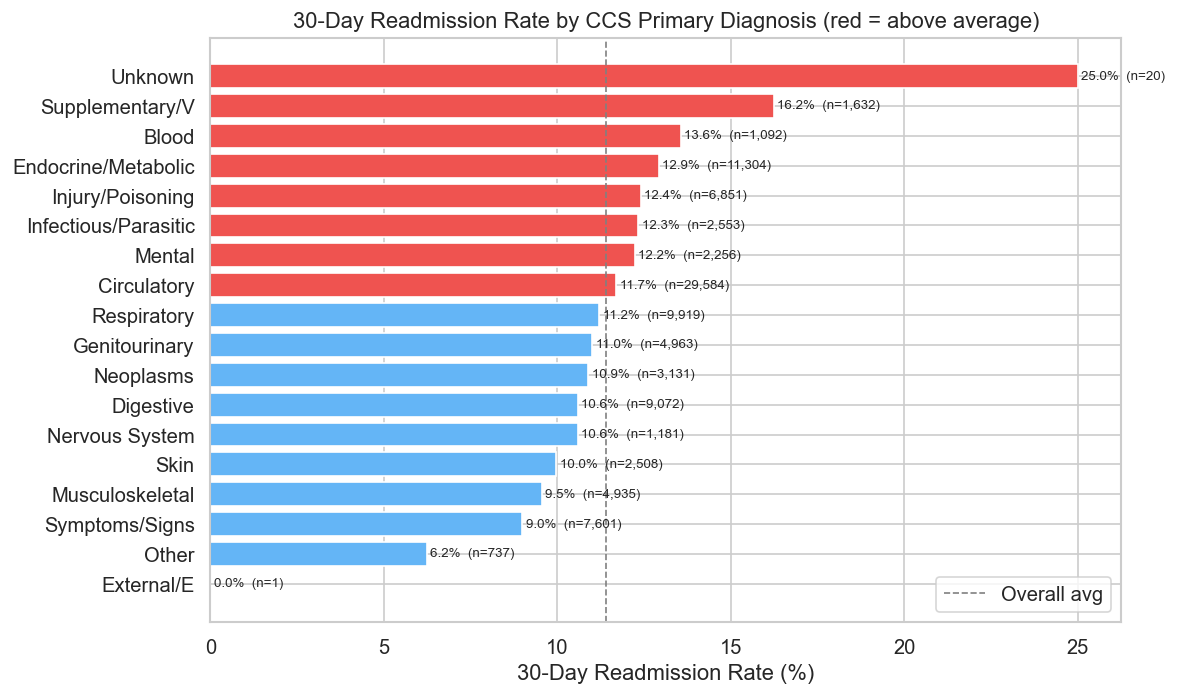

In [7]:
# Readmission rate by CCS primary diagnosis category
grp = df.groupby("ccs_diag_1")["readmit_30"].agg(["mean", "count"])
grp["mean"] *= 100
grp = grp.sort_values("mean", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ["#EF5350" if v > df["readmit_30"].mean()*100 else "#64B5F6"
          for v in grp["mean"]]
ax.barh(grp.index, grp["mean"], color=colors, edgecolor="white")
ax.axvline(df["readmit_30"].mean()*100, color="gray", linestyle="--", linewidth=1, label="Overall avg")
for i, (idx, row) in enumerate(grp.iterrows()):
    ax.text(row["mean"] + 0.1, i, f"{row['mean']:.1f}%  (n={int(row['count']):,})",
            va="center", fontsize=8)
ax.set_xlabel("30-Day Readmission Rate (%)")
ax.set_title("30-Day Readmission Rate by CCS Primary Diagnosis (red = above average)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. Charlson Comorbidity Index

Approximate Charlson Comorbidity Index (CCI) from the three diagnosis code slots.
CCI summarizes comorbidity burden into a single score; higher scores correlate with higher mortality and readmission risk.

In [8]:
def get_charlson_score(diag_list):
    """Approximate Charlson Comorbidity Index from a list of ICD-9 code strings."""
    nums = []
    for c in diag_list:
        if pd.isna(c):
            continue
        c_str = str(c).strip().upper()
        if c_str.startswith(("V", "E")):
            continue
        try:
            nums.append(float(c_str.split(".")[0]))
        except ValueError:
            continue

    def in_r(lo, hi): return any(lo <= n <= hi for n in nums)
    def has(val):     return val in nums

    score = 0
    # 1-point conditions
    if in_r(410, 412): score += 1  # Myocardial infarction
    if has(428):       score += 1  # Congestive heart failure
    if in_r(440, 444): score += 1  # Peripheral vascular disease
    if in_r(430, 438): score += 1  # Cerebrovascular disease
    if in_r(290, 294): score += 1  # Dementia
    if in_r(490, 506): score += 1  # Chronic pulmonary disease
    if in_r(710, 710) or has(714) or has(725): score += 1  # Connective tissue disease
    if in_r(531, 534): score += 1  # Peptic ulcer disease
    if has(571) or in_r(573, 573): score += 1  # Mild liver disease
    if in_r(250, 250): score += 1  # Diabetes (any)
    # 2-point conditions
    if has(342) or has(344): score += 2  # Hemiplegia/paraplegia
    if in_r(582, 586):       score += 2  # Moderate/severe renal disease
    if in_r(140, 195):       score += 2  # Any malignancy (non-metastatic)
    # 3-point conditions
    if has(456) or has(572): score += 3  # Moderate/severe liver disease
    # 6-point conditions
    if in_r(196, 199): score += 6  # Metastatic solid tumor
    if in_r(42, 44):   score += 6  # AIDS/HIV

    return score

df["charlson_score"] = df.apply(
    lambda r: get_charlson_score([r["diag_1"], r["diag_2"], r["diag_3"]]), axis=1
)

print(df["charlson_score"].value_counts().sort_index().to_string())
print(f"\nMean CCI: {df['charlson_score'].mean():.2f}")
print(f"Correlation with readmit_30: {df['charlson_score'].corr(df['readmit_30']):.3f}")

charlson_score
0     24625
1     45809
2     20211
3      5795
4      1054
5        74
6       553
7       243
8       751
9       220
10        5

Mean CCI: 1.22
Correlation with readmit_30: 0.042


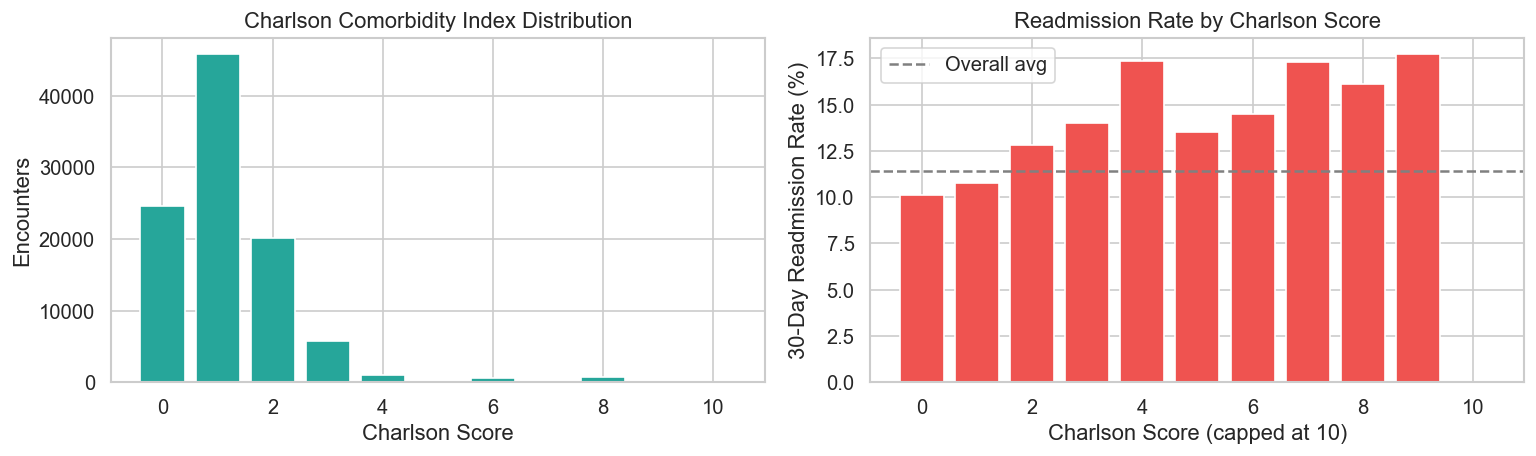

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of CCI scores
ax = axes[0]
cci_dist = df["charlson_score"].value_counts().sort_index()
ax.bar(cci_dist.index, cci_dist.values, color="#26A69A", edgecolor="white")
ax.set_xlabel("Charlson Score")
ax.set_ylabel("Encounters")
ax.set_title("Charlson Comorbidity Index Distribution")

# Readmission rate by CCI score (capped at 10 for readability)
ax = axes[1]
grp = df[df["charlson_score"] <= 10].groupby("charlson_score")["readmit_30"].agg(["mean", "count"])
ax.bar(grp.index, grp["mean"] * 100, color="#EF5350", edgecolor="white")
ax.axhline(df["readmit_30"].mean() * 100, color="gray", linestyle="--", label="Overall avg")
ax.set_xlabel("Charlson Score (capped at 10)")
ax.set_ylabel("30-Day Readmission Rate (%)")
ax.set_title("Readmission Rate by Charlson Score")
ax.legend()

plt.tight_layout()
plt.show()

## 5. Medication Features

Encode the 18 remaining medication columns as binary flags (0 = not used, 1 = used).
Create a **medication burden score** = total number of active medications.
Encode `change` and `diabetesMed` as binary flags.

In [10]:
MED_COLS = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide",
    "glimepiride", "acetohexamide", "glipizide", "glyburide",
    "tolbutamide", "pioglitazone", "rosiglitazone", "acarbose",
    "miglitol", "tolazamide", "insulin",
    "glyburide-metformin", "glipizide-metformin", "metformin-rosiglitazone"
]

# Binary: any non-'No' value means the drug was active/adjusted
for col in MED_COLS:
    df[f"{col}_used"] = (df[col] != "No").astype(int)

# Medication burden = number of active medications
df["med_burden_score"] = df[[f"{c}_used" for c in MED_COLS]].sum(axis=1)

# Medication change flags
df["change_flag"]      = (df["change"] == "Ch").astype(int)
df["diabetes_med_flag"] = (df["diabetesMed"] == "Yes").astype(int)

# Drop original medication columns and change/diabetesMed
df = df.drop(columns=MED_COLS + ["change", "diabetesMed"])

print(f"Med burden score — mean: {df['med_burden_score'].mean():.2f}, "
      f"max: {df['med_burden_score'].max()}")
print(f"Correlation with readmit_30: {df['med_burden_score'].corr(df['readmit_30']):.3f}")

Med burden score — mean: 1.19, max: 6
Correlation with readmit_30: 0.001


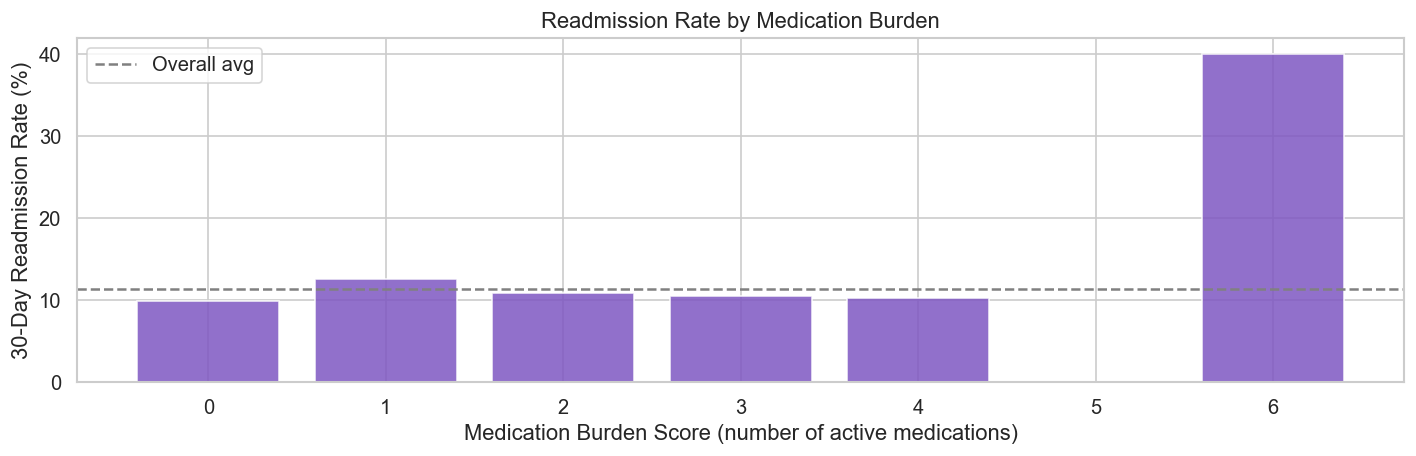

In [11]:
# Readmission rate by medication burden score
fig, ax = plt.subplots(figsize=(12, 4))
grp = df.groupby("med_burden_score")["readmit_30"].agg(["mean", "count"])
ax.bar(grp.index, grp["mean"] * 100, color="#7E57C2", edgecolor="white", alpha=0.85)
ax.axhline(df["readmit_30"].mean() * 100, color="gray", linestyle="--", label="Overall avg")
ax.set_xlabel("Medication Burden Score (number of active medications)")
ax.set_ylabel("30-Day Readmission Rate (%)")
ax.set_title("Readmission Rate by Medication Burden")
ax.legend()
plt.tight_layout()
plt.show()

## 6. Demographic & Lab Encoding

In [12]:
# Age: convert decade bins to numeric midpoint (e.g. [50-60) -> 55)
AGE_MID = {
    "[0-10)": 5, "[10-20)": 15, "[20-30)": 25, "[30-40)": 35,
    "[40-50)": 45, "[50-60)": 55, "[60-70)": 65, "[70-80)": 75,
    "[80-90)": 85, "[90-100)": 95
}
df["age_mid"] = df["age"].map(AGE_MID)

# Gender: binary flag
df["gender_male"] = (df["gender"] == "Male").astype(int)

# HbA1c result — ordinal + binary tested flag
# 'None' = not tested (83.3% of encounters) — NOT a missing value, treat as informative
A1C_MAP = {"None": 0, "Norm": 1, ">7": 2, ">8": 3}
df["a1c_ordinal"] = df["A1Cresult"].map(A1C_MAP)
df["a1c_tested"]  = (df["A1Cresult"] != "None").astype(int)

# Max glucose serum — ordinal + binary tested flag
GLU_MAP = {"None": 0, "Norm": 1, ">200": 2, ">300": 3}
df["glu_ordinal"] = df["max_glu_serum"].map(GLU_MAP)
df["glu_tested"]  = (df["max_glu_serum"] != "None").astype(int)

print("A1C ordinal distribution:")
print(df["a1c_ordinal"].value_counts().sort_index().to_string())
print("\nGlucose ordinal distribution:")
print(df["glu_ordinal"].value_counts().sort_index().to_string())

A1C ordinal distribution:
a1c_ordinal
1.0    4922
2.0    3775
3.0    8137

Glucose ordinal distribution:
glu_ordinal
1.0    2545
2.0    1419
3.0    1188


## 7. Aggregated Features

In [13]:
# Total prior healthcare utilization (sum of outpatient + emergency + inpatient visits)
df["total_prior_visits"]   = (df["number_outpatient"]
                               + df["number_emergency"]
                               + df["number_inpatient"])
df["has_prior_inpatient"]  = (df["number_inpatient"] > 0).astype(int)
# Log-transform to compress the heavy right skew (most patients have 0 prior visits)
df["log_prior_visits"]     = np.log1p(df["total_prior_visits"])

# Care intensity composite — normalized sum of hospital utilization metrics
# (Note: max values are from full dataset; in production use training set max)
df["care_intensity"] = (
    df["time_in_hospital"]  / df["time_in_hospital"].max()
    + df["num_lab_procedures"] / df["num_lab_procedures"].max()
    + df["num_procedures"]    / df["num_procedures"].max()
    + df["num_medications"]   / df["num_medications"].max()
)

print("New aggregated features:")
for col in ["total_prior_visits", "log_prior_visits", "care_intensity", "has_prior_inpatient"]:
    print(f"  {col}: mean={df[col].mean():.3f}, corr_with_target={df[col].corr(df['readmit_30']):.3f}")

New aggregated features:
  total_prior_visits: mean=1.199, corr_with_target=0.128
  log_prior_visits: mean=0.513, corr_with_target=0.137
  care_intensity: mean=1.058, corr_with_target=0.029
  has_prior_inpatient: mean=0.333, corr_with_target=0.125


## 8. Engineered Feature Correlations with Target

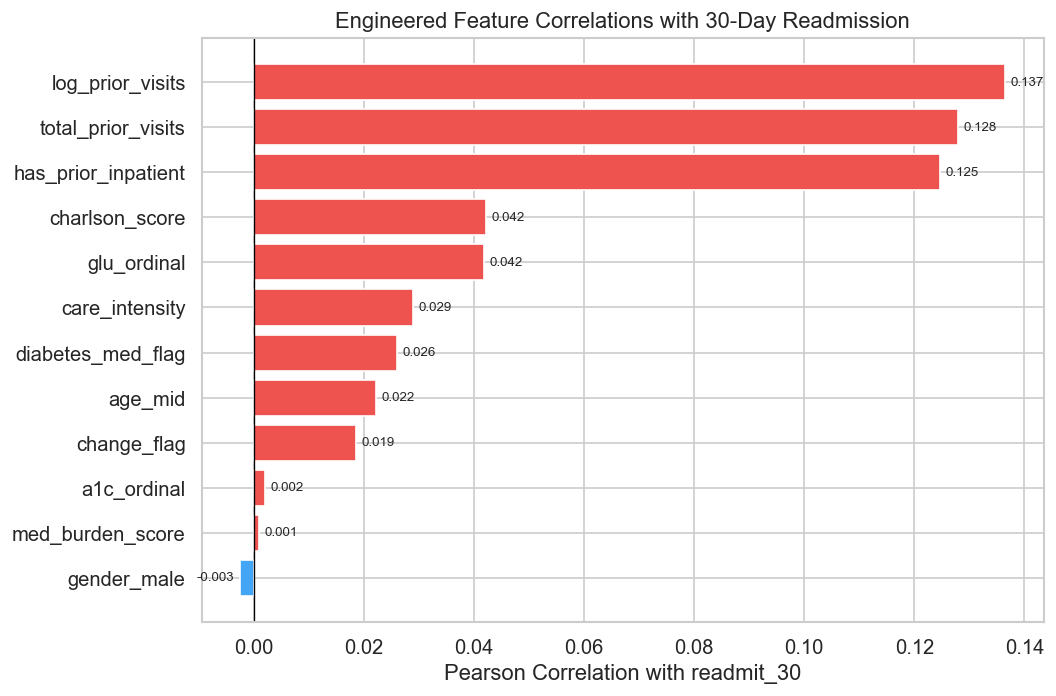

In [14]:
ENGINEERED = [
    "charlson_score", "med_burden_score", "care_intensity",
    "total_prior_visits", "log_prior_visits", "has_prior_inpatient",
    "age_mid", "gender_male", "a1c_ordinal", "a1c_tested",
    "glu_ordinal", "glu_tested", "change_flag", "diabetes_med_flag"
]

corrs = df[ENGINEERED + ["readmit_30"]].corr()["readmit_30"].drop("readmit_30").sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["#EF5350" if v > 0 else "#42A5F5" for v in corrs.values]
ax.barh(corrs.index, corrs.values, color=colors, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Pearson Correlation with readmit_30")
ax.set_title("Engineered Feature Correlations with 30-Day Readmission")
for i, (idx, v) in enumerate(corrs.items()):
    ax.text(v + (0.001 if v >= 0 else -0.001), i, f"{v:.3f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=8)
plt.tight_layout()
plt.show()

## 9. Patient-Level Train / Val / Test Split

**Why patient-level?** 16,773 patients have multiple encounters. A random encounter-level split would put the same patient in both train and test, leaking label information.

Strategy: shuffle unique patients, then assign 70% to train, 15% to val, 15% to test by `patient_nbr`.

In [15]:
np.random.seed(42)
patients = df["patient_nbr"].unique()
np.random.shuffle(patients)

n = len(patients)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_patients = set(patients[:n_train])
val_patients   = set(patients[n_train : n_train + n_val])
test_patients  = set(patients[n_train + n_val:])

train_df = df[df["patient_nbr"].isin(train_patients)].copy()
val_df   = df[df["patient_nbr"].isin(val_patients)].copy()
test_df  = df[df["patient_nbr"].isin(test_patients)].copy()

# Sanity checks — no patient overlap
assert len(train_patients & val_patients)  == 0, "Train/Val patient overlap!"
assert len(train_patients & test_patients) == 0, "Train/Test patient overlap!"
assert len(val_patients   & test_patients) == 0, "Val/Test patient overlap!"
assert len(train_df) + len(val_df) + len(test_df) == len(df), "Row count mismatch!"

print(f"{'Split':<10} {'Patients':>10} {'Encounters':>12} {'Pos rate':>10}")
print("-" * 45)
for name, split, pats in [("Train", train_df, train_patients),
                          ("Val",   val_df,   val_patients),
                          ("Test",  test_df,  test_patients)]:
    print(f"{name:<10} {len(pats):>10,} {len(split):>12,} "
          f"{split['readmit_30'].mean()*100:>9.1f}%")
print(f"\nNo patient overlap confirmed.")

Split        Patients   Encounters   Pos rate
---------------------------------------------
Train          48,990       69,652      11.5%
Val            10,498       14,822      11.0%
Test           10,499       14,866      11.0%

No patient overlap confirmed.


## 10. Save Processed Datasets

In [16]:
OUT_DIR = "../data/processed"
os.makedirs(OUT_DIR, exist_ok=True)

train_df.to_csv(f"{OUT_DIR}/train.csv", index=False)
val_df.to_csv(f"{OUT_DIR}/val.csv",     index=False)
test_df.to_csv(f"{OUT_DIR}/test.csv",   index=False)
df.to_csv(f"{OUT_DIR}/features_full.csv", index=False)

print(f"Saved to {OUT_DIR}/")
print(f"  train.csv         : {len(train_df):,} rows")
print(f"  val.csv           : {len(val_df):,} rows")
print(f"  test.csv          : {len(test_df):,} rows")
print(f"  features_full.csv : {len(df):,} rows")
print(f"\nFinal feature count: {df.shape[1]} columns")
print(f"\nAll columns:")
print(list(df.columns))

Saved to ../data/processed/
  train.csv         : 69,652 rows
  val.csv           : 14,822 rows
  test.csv          : 14,866 rows
  features_full.csv : 99,340 rows

Final feature count: 63 columns

All columns:
['encounter_id', 'patient_nbr', 'race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'payer_code', 'medical_specialty', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'diag_1', 'diag_2', 'diag_3', 'number_diagnoses', 'max_glu_serum', 'A1Cresult', 'readmitted', 'readmit_30', 'admission_type_cat', 'discharge_cat', 'admission_source_cat', 'ccs_diag_1', 'ccs_diag_2', 'ccs_diag_3', 'charlson_score', 'metformin_used', 'repaglinide_used', 'nateglinide_used', 'chlorpropamide_used', 'glimepiride_used', 'acetohexamide_used', 'glipizide_used', 'glyburide_used', 'tolbutamide_used', 'pioglitazone_used', 'rosiglitazone_used', 'acarbose_used', 'miglitol_used'